In [ ]:
# step-0: installation & set-up
!pip install kaggle -q
import os, random, re, shutil, math
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow.keras.regularizers import l2
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50, MobileNet
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet import preprocess_input as mobilenet_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_recall_fscore_support, roc_curve,f1_score
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# step-1: BUSI dataset download from kaggle
from google.colab import files
uploaded = files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
shutil.copy('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!kaggle datasets download -d aryashah2k/breast-ultrasound-images-dataset
!unzip -q breast-ultrasound-images-dataset.zip -d /content/BUSI
print('Dataset ready!')

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset
License(s): CC0-1.0
100% 195M/195M [00:05<00:00, 37.2MB/s]

Dataset ready!


In [ ]:
# auto-detecting dataset path
def find_busi_path(base='/content/BUSI'):
    for root, dirs, files in os.walk(base):
        if 'benign' in dirs and 'malignant' in dirs and 'normal' in dirs:
            print(f'found BUSI dataset at: {root}')
            return root
    raise FileNotFoundError('BUSI folders not found.')

DATASET_PATH = find_busi_path()
for cls in ['benign','malignant','normal']:
    n = len([f for f in os.listdir(os.path.join(DATASET_PATH, cls))
             if '_mask' not in f and f.endswith('.png')])
    print(f'  {cls}: {n} images')

found BUSI dataset at: /content/BUSI/Dataset_BUSI_with_GT
  benign: 437 images
  malignant: 210 images
  normal: 133 images


In [ ]:
# step-2: configuration
OUTPUT_DIR = '/content/outputs_a3'
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_SIZE    = 224
BATCH_SIZE  = 32
CLASSES     = ['benign', 'malignant', 'normal']
CLASS_NAMES = ['Benign', 'Malignant', 'Normal']
NUM_CLASSES = 3

LR_PHASE1    = 1e-3
LR_PHASE2    = 1e-5
EPOCHS_P1    = 10
EPOCHS_P2    = 10

print('Configuration loaded.')
print(f'Output directory: {OUTPUT_DIR}')

Configuration loaded.
Output directory: /content/outputs_a3


In [ ]:
# step-3: patient hold-out split — identical to assignment 2

def load_busi_records(root_dir):
    records = []
    for label in CLASSES:
        folder = os.path.join(root_dir, label)
        if not os.path.isdir(folder): continue
        for fname in sorted(os.listdir(folder)):
            if '_mask' in fname or not fname.endswith('.png'): continue
            match = re.search(r'\((\d+)\)', fname)
            pid = f"{label}_{match.group(1)}" if match else f"{label}_{fname}"
            records.append({'patient_id': pid, 'label': label,
                            'filepath': os.path.join(folder, fname)})
    print(f'loaded {len(records)} images (masks excluded)')
    return records

def patient_holdout_split(records, train_ratio=0.70, val_ratio=0.15, seed=42):
    rng = random.Random(seed)
    by_patient = defaultdict(list)
    for r in records:
        by_patient[r['patient_id']].append(r)
    by_label = defaultdict(list)
    for pid, recs in by_patient.items():
        labels = [r['label'] for r in recs]
        majority = max(set(labels), key=labels.count)
        by_label[majority].append(pid)
    train_pids, val_pids, test_pids = [], [], []
    for label, pids in by_label.items():
        rng.shuffle(pids)
        n = len(pids)
        n_train = int(n * train_ratio)
        n_val   = int(n * val_ratio)
        train_pids += pids[:n_train]
        val_pids   += pids[n_train:n_train+n_val]
        test_pids  += pids[n_train+n_val:]
    assert len(set(train_pids) & set(val_pids))  == 0
    assert len(set(train_pids) & set(test_pids)) == 0
    assert len(set(val_pids)   & set(test_pids)) == 0
    def collect(pids):
        result = []
        for pid in pids:
            result.extend(by_patient[pid])
        return result
    train_recs = collect(train_pids)
    val_recs   = collect(val_pids)
    test_recs  = collect(test_pids)
    info = {
        'total_images':   len(records),   'total_patients': len(by_patient),
        'train_images':   len(train_recs),'train_patients': len(train_pids),
        'val_images':     len(val_recs),  'val_patients':   len(val_pids),
        'test_images':    len(test_recs), 'test_patients':  len(test_pids),
    }
    return train_recs, val_recs, test_recs, info

records = load_busi_records(DATASET_PATH)
train_recs, val_recs, test_recs, split_info = patient_holdout_split(records)
print(f"Train: {split_info['train_images']} | Val: {split_info['val_images']} | Test: {split_info['test_images']}")
print('Patient overlap: 0 (verified ✓)')

loaded 780 images (masks excluded)
Train: 545 | Val: 115 | Test: 120
Patient overlap: 0 (verified ✓)


In [ ]:
# step-4: preprocessing pipeline (same as assignment 2)
# CLAHE → Gaussian denoise → RGB → resize → normalize
# augmentation applied to training only

def preprocess_image(filepath, augment=False, model_type='resnet'):
    img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
    if img is None:
        img = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img   = clahe.apply(img)
    # Gaussian denoise
    img = cv2.GaussianBlur(img, (3, 3), 0)
    # grayscale → 3-channel RGB
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    # resize
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
    img = img.astype(np.float32)

    if augment:
        if random.random() > 0.5: img = img[:, ::-1, :]
        if random.random() > 0.5: img = img[::-1, :, :]
        angle = random.uniform(-25, 25)
        M = cv2.getRotationMatrix2D((IMG_SIZE//2, IMG_SIZE//2), angle, 1.0)
        img = cv2.warpAffine(img, M, (IMG_SIZE, IMG_SIZE), borderMode=cv2.BORDER_REFLECT)
        if random.random() > 0.5:
            scale = random.uniform(0.8, 1.2)
            M2 = cv2.getRotationMatrix2D((IMG_SIZE//2, IMG_SIZE//2), 0, scale)
            img = cv2.warpAffine(img, M2, (IMG_SIZE, IMG_SIZE), borderMode=cv2.BORDER_REFLECT)
        if random.random() > 0.5:
            img = np.clip(img * random.uniform(0.8, 1.2), 0, 255)
        if random.random() > 0.5:
            img = np.clip(img + np.random.normal(0, 12, img.shape).astype(np.float32), 0, 255)

    # using correct normalization per model
    if model_type == 'mobilenet':
        img = mobilenet_preprocess(img)
    else:
        img = resnet_preprocess(img)
    return img.astype(np.float32)


class BUSIDataGenerator(keras.utils.Sequence):
    def __init__(self, records, batch_size=32, augment=False, shuffle=True, model_type='resnet'):
        self.records    = records
        self.batch_size = batch_size
        self.augment    = augment
        self.shuffle    = shuffle
        self.model_type = model_type
        self.label_map  = {c: i for i, c in enumerate(CLASSES)}
        self.indices    = np.arange(len(records))
        if shuffle: np.random.shuffle(self.indices)
    def __len__(self):
        return int(np.ceil(len(self.records) / self.batch_size))
    def __getitem__(self, idx):
        batch_idx = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        X = np.zeros((len(batch_idx), IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
        y = np.zeros((len(batch_idx), NUM_CLASSES), dtype=np.float32)
        for i, bi in enumerate(batch_idx):
            rec = self.records[bi]
            X[i] = preprocess_image(rec['filepath'], augment=self.augment, model_type=self.model_type)
            y[i, self.label_map[rec['label']]] = 1.0
        return X, y
    def on_epoch_end(self):
        if self.shuffle: np.random.shuffle(self.indices)

# generators for Part A (ResNet backbone)
train_gen_a = BUSIDataGenerator(train_recs, BATCH_SIZE, augment=True,  shuffle=True,  model_type='resnet')
val_gen_a   = BUSIDataGenerator(val_recs,   BATCH_SIZE, augment=False, shuffle=False, model_type='resnet')
test_gen_a  = BUSIDataGenerator(test_recs,  BATCH_SIZE, augment=False, shuffle=False, model_type='resnet')

# generators for Part B (MobileNetV1)
train_gen_b = BUSIDataGenerator(train_recs, BATCH_SIZE, augment=True,  shuffle=True,  model_type='mobilenet')
val_gen_b   = BUSIDataGenerator(val_recs,   BATCH_SIZE, augment=False, shuffle=False, model_type='mobilenet')
test_gen_b  = BUSIDataGenerator(test_recs,  BATCH_SIZE, augment=False, shuffle=False, model_type='mobilenet')

print(f'Train batches: {len(train_gen_a)} | Val: {len(val_gen_a)} | Test: {len(test_gen_a)}')

Train batches: 18 | Val: 4 | Test: 4


In [ ]:
# step-5: class weights for class imbalance
# same balanced weights used in both Part A and Part B

train_labels  = [r['label'] for r in train_recs]
label_indices = [CLASSES.index(l) for l in train_labels]
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=label_indices
)
class_weight_dict = {i: w for i, w in enumerate(class_weights_arr)}
print('class weights:', {CLASSES[i]: round(float(class_weights_arr[i]),4) for i in range(NUM_CLASSES)})
print()
print('Loss function: Categorical Cross-Entropy')
print('Property 1: Monotonically increasing (-log(p) increases as p decreases)')
print('Property 2: Differentiable — gradient = y_pred - y_true (smooth everywhere)')
print('Property 3: Faster convergence — gradient proportional to prediction error')

class weights: {'benign': 0.5956, 'malignant': 1.2358, 'normal': 1.9534}

Loss function: Categorical Cross-Entropy
Property 1: Monotonically increasing (-log(p) increases as p decreases)
Property 2: Differentiable — gradient = y_pred - y_true (smooth everywhere)
Property 3: Faster convergence — gradient proportional to prediction error


In [ ]:
# PART-A:
# step-6: DSC calculation

print('DSC computational savings using the formula')

K    = 3      # kernel size
Cout = 32     # output channels (typical first DSC layer)
ratio = (1/Cout) + (1/K**2)
savings = (1 - ratio) * 100

print(f'Kernel size K       = {K}')
print(f'Output channels     = {Cout}')
print(f'C(DSC)/C(RC) ratio  = 1/{Cout} + 1/{K}^2')
print(f'                    = {1/Cout:.4f} + {1/K**2:.4f}')
print(f'                    = {ratio:.4f}')
print(f'Computational saving = {savings:.1f}%')
print()

# showing ratio for different Cout values
print('Ratio for different Cout values (K=3):')
print(f'  {"Cout":>6} | {"Ratio":>8} | {"Saving":>8}')
print(f'  {"-"*6}-+-{"-"*8}-+-{"-"*8}')
for c in [8, 16, 32, 64, 128, 256]:
    r = (1/c) + (1/9)
    print(f'  {c:>6} | {r:>8.4f} | {(1-r)*100:>7.1f}%')

DSC computational savings using the formula
Kernel size K       = 3
Output channels     = 32
C(DSC)/C(RC) ratio  = 1/32 + 1/3^2
                    = 0.0312 + 0.1111
                    = 0.1424
Computational saving = 85.8%

Ratio for different Cout values (K=3):
    Cout |    Ratio |   Saving
  -------+----------+---------
       8 |   0.2361 |    76.4%
      16 |   0.1736 |    82.6%
      32 |   0.1424 |    85.8%
      64 |   0.1267 |    87.3%
     128 |   0.1189 |    88.1%
     256 |   0.1150 |    88.5%


In [ ]:
# step-7: Part A — ResNet50 backbone + DSC classification head + ELU

def build_dsc_block(x, filters, stride=1):

    # Depthwise: each channel convolved independently
    x = layers.DepthwiseConv2D(
        kernel_size=3, strides=stride, padding='same',
        use_bias=False
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('elu')(x)

    # Pointwise: 1x1 conv to mix channel information
    x = layers.Conv2D(
        filters, kernel_size=1, strides=1, padding='same',
        use_bias=False
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('elu')(x)
    return x

def build_part_a_model(num_classes=3, input_shape=(224, 224, 3)):

    inputs   = keras.Input(shape=input_shape)
    backbone = ResNet50(include_top=False, weights='imagenet', input_tensor=inputs)
    backbone.trainable = False

    x = backbone.output               # (7, 7, 2048)

    # DSC block 1: 2048 -> 512
    x = build_dsc_block(x, filters=512)
    x = layers.Dropout(0.3)(x)

    # DSC block 2: 512 -> 128
    x = build_dsc_block(x, filters=128)
    x = layers.Dropout(0.2)(x)

    # Pool then classify
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=backbone.input, outputs=outputs)
    return model, backbone


model_a, backbone_a = build_part_a_model()
model_a.summary()
trainable_a = sum([tf.size(v).numpy() for v in model_a.trainable_variables])
total_a     = model_a.count_params()
print(f'\nTotal params    : {total_a:,}')
print(f'Trainable params: {trainable_a:,}')


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,738,051 (94.37 MB)

 Trainable params: 1,143,939 (4.36 MB)

 Non-trainable params: 23,594,112 (90.00 MB)


Total params    : 24,738,051
Trainable params: 1,143,939


In [ ]:
# step-8: Part A — Phase 1 training (backbone frozen, DSC head only)

model_a.compile(
    optimizer=keras.optimizers.Adam(learning_rate=2e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_a_p1 = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-7),
    ModelCheckpoint(f'{OUTPUT_DIR}/partA_phase1.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1),
]

print('Part A — Phase 1: training DSC head only (backbone frozen)')
history_a_p1 = model_a.fit(
    train_gen_a, validation_data=val_gen_a,
    epochs=EPOCHS_P1, callbacks=callbacks_a_p1,
    class_weight=class_weight_dict, verbose=1
)
print(f'Phase 1 done. Best val_accuracy: {max(history_a_p1.history["val_accuracy"]):.4f}')

Part A — Phase 1: training DSC head only (backbone frozen)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4714 - loss: 0.9968
Epoch 1: val_accuracy improved from None to 0.56522, saving model to /content/outputs_a3/partA_phase1.keras

Epoch 1: finished saving model to /content/outputs_a3/partA_phase1.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.5468 - loss: 0.9434 - val_accuracy: 0.5652 - val_loss: 1.0237 - learning_rate: 0.0020
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.6689 - loss: 0.6911
Epoch 2: val_accuracy improved from 0.56522 to 0.60870, saving model to /content/outputs_a3/partA_phase1.keras

Epoch 2: finished saving model to /content/outputs_a3/partA_phase1.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 658ms/step - accuracy: 0.6917 - loss: 0.6728 - val_accuracy: 0.6087 - val_loss: 0.9412 - learning_rate: 0.0020
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step - accuracy: 0.6951 - loss: 0.6360
Epoch 3: val_accuracy did not improve from 0.60870
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 641ms/step - ac

In [ ]:
# step-9: Part A — Phase 2 fine-tuning (unfreezing conv5_block)

backbone_a.trainable = True
for layer in backbone_a.layers:
    layer.trainable = True if 'conv5_block' in layer.name else False

trainable_a_p2 = sum([tf.size(v).numpy() for v in model_a.trainable_variables])
print(f'Phase 2 trainable params: {trainable_a_p2:,}')

model_a.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_PHASE2),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_a_p2 = [
    EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-8),
    ModelCheckpoint(f'{OUTPUT_DIR}/partA_final.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1),
]

print('Part A — Phase 2: fine-tuning conv5_block + DSC head')
history_a_p2 = model_a.fit(
    train_gen_a, validation_data=val_gen_a,
    epochs=EPOCHS_P2, callbacks=callbacks_a_p2,
    class_weight=class_weight_dict, verbose=1
)

Phase 2 trainable params: 16,119,939
Part A — Phase 2: fine-tuning conv5_block + DSC head
Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6777 - loss: 0.6471
Epoch 1: val_accuracy improved from None to 0.67826, saving model to /content/outputs_a3/partA_final.keras

Epoch 1: finished saving model to /content/outputs_a3/partA_final.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.7229 - loss: 0.5794 - val_accuracy: 0.6783 - val_loss: 0.8042 - learning_rate: 1.0000e-05
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.7326 - loss: 0.5273
Epoch 2: val_accuracy improved from 0.67826 to 0.69565, saving model to /content/outputs_a3/partA_final.keras

Epoch 2: finished saving model to /content/outputs_a3/partA_final.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 670ms/step - accuracy: 0.7413 - loss: 0.5258 - val_accuracy: 0.6957 - val_loss: 0.7865 - learning_rate: 1.0000e-05
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.7567 - loss: 0.4677
Epo

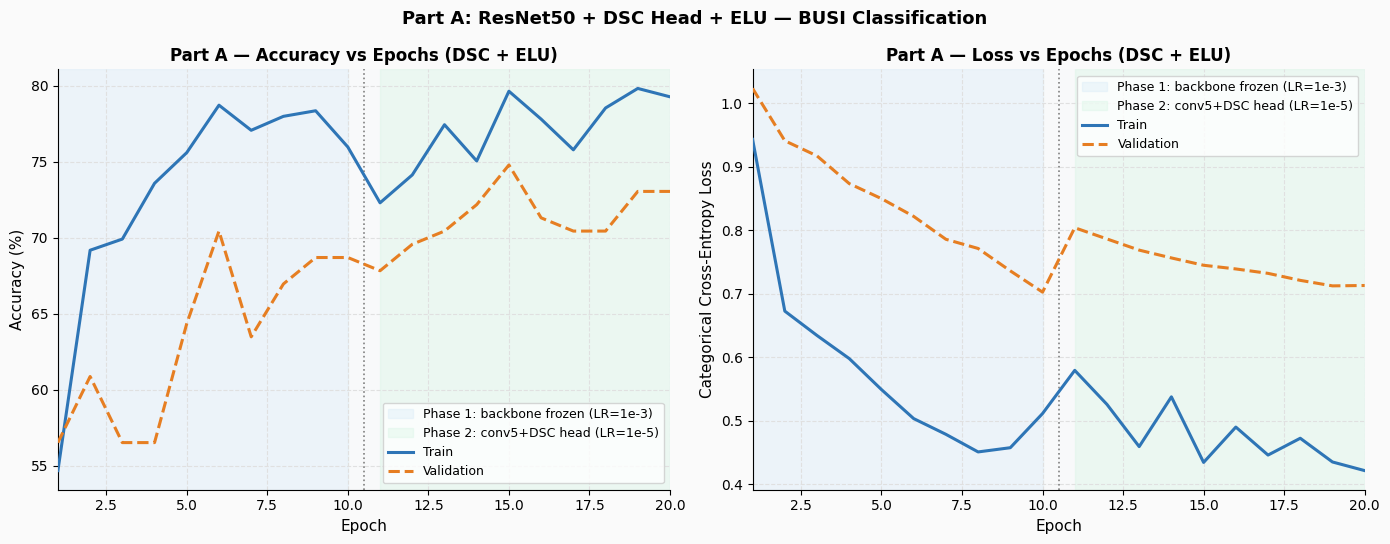

4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step

 Part A Test Evaluation 
Test images  : 120
Overall Accuracy: 67.50%

              precision    recall  f1-score   support

      Benign     0.8000    0.7761    0.7879        67
   Malignant     0.5098    0.8125    0.6265        32
      Normal     0.7500    0.1429    0.2400        21

    accuracy                         0.6750       120
   macro avg     0.6866    0.5772    0.5515       120
weighted avg     0.7139    0.6750    0.6490       120



In [ ]:
# step-10: Part A — training curves + test evaluation

# Training curves
def merge_histories(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    return merged

history_a = merge_histories(history_a_p1, history_a_p2)
epochs_a   = len(history_a['accuracy'])
ep_a       = np.arange(1, epochs_a + 1)
p1_end_a   = len(history_a_p1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor('#FAFAFA')
ph_colors = ['#D6EAF8', '#D5F5E3']
ph_labels = ['Phase 1: backbone frozen (LR=1e-3)', 'Phase 2: conv5+DSC head (LR=1e-5)']

for ax, (ytr, yv, title, ylabel) in zip(axes, [
    (np.array(history_a['accuracy'])*100, np.array(history_a['val_accuracy'])*100,
     'Part A — Accuracy vs Epochs (DSC + ELU)', 'Accuracy (%)'),
    (history_a['loss'], history_a['val_loss'],
     'Part A — Loss vs Epochs (DSC + ELU)', 'Categorical Cross-Entropy Loss'),
]):
    ax.set_facecolor('#F8F9FA')
    ax.grid(True, color='#E0E0E0', linewidth=0.8, linestyle='--')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.axvspan(1, p1_end_a, alpha=0.35, color=ph_colors[0], label=ph_labels[0])
    ax.axvspan(p1_end_a+1, epochs_a, alpha=0.35, color=ph_colors[1], label=ph_labels[1])
    ax.plot(ep_a, ytr, color='#2E75B6', lw=2.2, label='Train', zorder=4)
    ax.plot(ep_a, yv,  color='#E67E22', lw=2.2, label='Validation', linestyle='--', zorder=4)
    ax.axvline(p1_end_a+0.5, color='gray', lw=1.2, linestyle=':')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=11); ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xlim(1, epochs_a)
    ax.legend(fontsize=9, loc='lower right' if 'Acc' in title else 'upper right')

plt.suptitle('Part A: ResNet50 + DSC Head + ELU — BUSI Classification', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/partA_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Test evaluation
best_a = keras.models.load_model(f'{OUTPUT_DIR}/partA_final.keras')
y_true = np.array([{c: i for i, c in enumerate(CLASSES)}[r['label']] for r in test_recs])
X_test_a = np.zeros((len(test_recs), IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
for i, rec in enumerate(test_recs):
    X_test_a[i] = preprocess_image(rec['filepath'], augment=False, model_type='resnet')

y_pred_prob_a = best_a.predict(X_test_a, batch_size=BATCH_SIZE, verbose=1)
y_pred_a      = np.argmax(y_pred_prob_a, axis=1)

print('\n Part A Test Evaluation ')
print(f'Test images  : {len(y_true)}')
print(f'Overall Accuracy: {accuracy_score(y_true, y_pred_a)*100:.2f}%')
print()
print(classification_report(y_true, y_pred_a, target_names=CLASS_NAMES, digits=4))

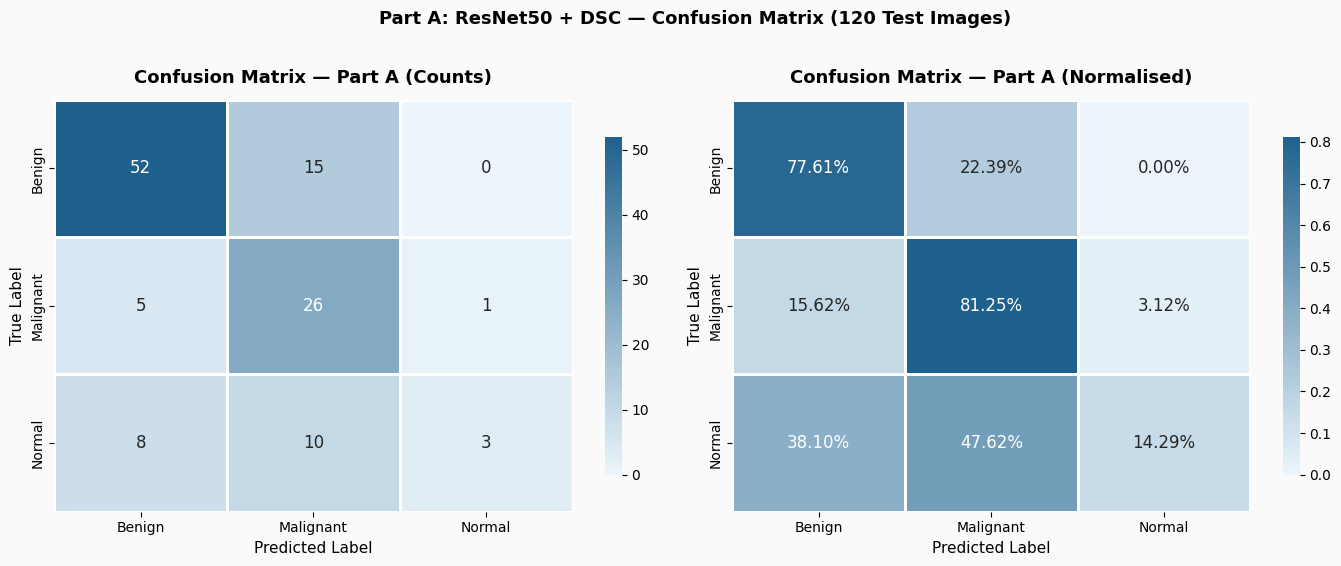

In [ ]:
# step-10b: Part A — confusion matrix
cm_a      = confusion_matrix(y_true, y_pred_a)
cm_a_norm = cm_a.astype(float) / cm_a.sum(axis=1, keepdims=True)
cmap      = LinearSegmentedColormap.from_list('busi', ['#EBF5FB', '#1F618D'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor('#FAFAFA')
for ax, data, fmt, title in zip(axes, [cm_a, cm_a_norm], ['d', '.2%'],
    ['Confusion Matrix — Part A (Counts)', 'Confusion Matrix — Part A (Normalised)']):
    ax.set_facecolor('#FAFAFA')
    sns.heatmap(data, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.8, linecolor='white',
                cbar_kws={'shrink': 0.82}, ax=ax, annot_kws={'size': 12})
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
plt.suptitle(f'Part A: ResNet50 + DSC — Confusion Matrix ({len(y_true)} Test Images)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/partA_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

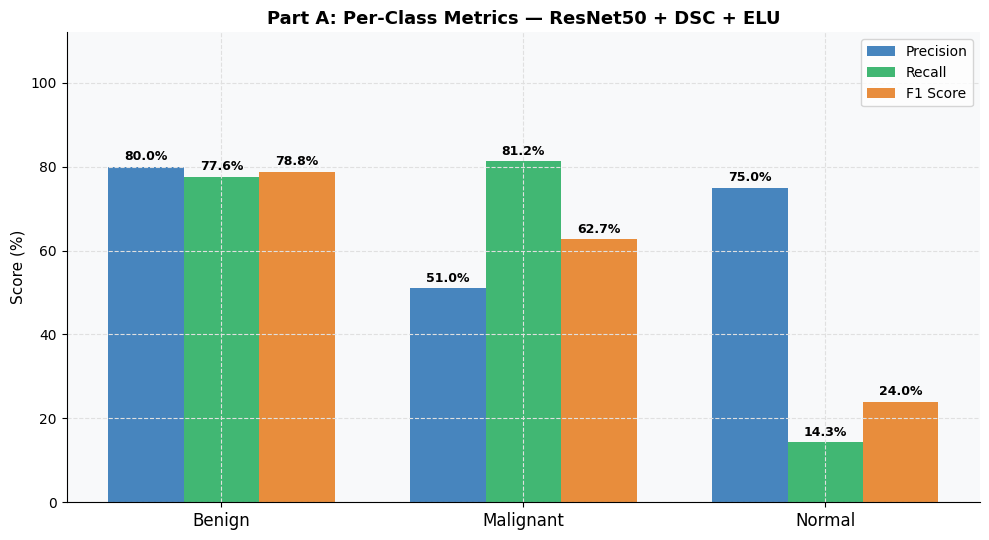

Part A — Macro F1: 0.5515
Part A — Trainable params (Phase 1): 1,143,939


In [ ]:
# step-10c: Part A — per-class metrics
p_a, r_a, f1_a, _ = precision_recall_fscore_support(y_true, y_pred_a, labels=list(range(NUM_CLASSES)))
x = np.arange(NUM_CLASSES); w = 0.25

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.set_facecolor('#F8F9FA'); ax.grid(True, color='#E0E0E0', linewidth=0.8, linestyle='--')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
b1 = ax.bar(x-w, p_a*100, w, label='Precision', color='#2E75B6', alpha=0.88)
b2 = ax.bar(x,   r_a*100, w, label='Recall',    color='#27AE60', alpha=0.88)
b3 = ax.bar(x+w, f1_a*100,w, label='F1 Score',  color='#E67E22', alpha=0.88)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.8, f'{h:.1f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, fontsize=12)
ax.set_ylabel('Score (%)', fontsize=11); ax.set_ylim(0, 112)
ax.set_title('Part A: Per-Class Metrics — ResNet50 + DSC + ELU', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/partA_per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

macro_f1_a = f1_score(y_true, y_pred_a, average='macro')
print(f'Part A — Macro F1: {macro_f1_a:.4f}')
print(f'Part A — Trainable params (Phase 1): {trainable_a:,}')

In [ ]:
# step-11: Part B — MobileNetV1 + ELU head

def build_mobilenet_model(num_classes=3, input_shape=(224, 224, 3)):
    inputs   = keras.Input(shape=input_shape)
    backbone = MobileNet(include_top=False, weights='imagenet',
                         input_tensor=inputs, alpha=1.0)
    backbone.trainable = False  # freezing initially

    x = backbone.output
    x = layers.GlobalAveragePooling2D()(x)

    # Head with ELU activation
    x = layers.Dense(256, kernel_regularizer=l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('elu')(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(64, kernel_regularizer=l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('elu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model   = Model(inputs=backbone.input, outputs=outputs)
    return model, backbone


model_b, backbone_b = build_mobilenet_model()
model_b.summary()
trainable_b = sum([tf.size(v).numpy() for v in model_b.trainable_variables])
total_b     = model_b.count_params()
print(f'\nTotal params    : {total_b:,}')
print(f'Trainable params: {trainable_b:,}')
print(f'\nComparison with Assignment 2 (ResNet50):')
print(f'  ResNet50 total params    : ~24,705,411')
print(f'  MobileNetV1 total params : {total_b:,}')
print(f'  Parameter reduction      : {(1 - total_b/24705411)*100:.1f}%')

/tmp/ipykernel_3045/1878983654.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = MobileNet(include_top=False, weights='imagenet',


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,509,187 (13.39 MB)

 Trainable params: 279,683 (1.07 MB)

 Non-trainable params: 3,229,504 (12.32 MB)


Total params    : 3,509,187
Trainable params: 279,683

Comparison with Assignment 2 (ResNet50):
  ResNet50 total params    : ~24,705,411
  MobileNetV1 total params : 3,509,187
  Parameter reduction      : 85.8%


In [ ]:
# step-12: Part B — Phase 1 (backbone frozen, head only)

model_b.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_PHASE1),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_b_p1 = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-7),
    ModelCheckpoint(f'{OUTPUT_DIR}/partB_phase1.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1),
]

print('Part B — Phase 1: training ELU head only (MobileNetV1 backbone frozen)')
history_b_p1 = model_b.fit(
    train_gen_b, validation_data=val_gen_b,
    epochs=EPOCHS_P1, callbacks=callbacks_b_p1,
    class_weight=class_weight_dict, verbose=1
)
print(f'Phase 1 done. Best val_accuracy: {max(history_b_p1.history["val_accuracy"]):.4f}')

Part B — Phase 1: training ELU head only (MobileNetV1 backbone frozen)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4354 - loss: 1.8346
Epoch 1: val_accuracy improved from None to 0.67826, saving model to /content/outputs_a3/partB_phase1.keras

Epoch 1: finished saving model to /content/outputs_a3/partB_phase1.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.4771 - loss: 1.7057 - val_accuracy: 0.6783 - val_loss: 1.2998 - learning_rate: 0.0010
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.5707 - loss: 1.4952
Epoch 2: val_accuracy did not improve from 0.67826
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 528ms/step - accuracy: 0.5835 - loss: 1.4420 - val_accuracy: 0.6783 - val_loss: 1.2518 - learning_rate: 0.0010
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.6781 - loss: 1.2616
Epoch 3: val_accuracy did not improve from 0.67826
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 542ms/step - accuracy: 0.6642 - loss: 1.2453 - val_accuracy: 0.6696 - val_loss: 1.2012 - learning_rate: 0.0010
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0

In [ ]:
# step-13: Part B — Phase 2 fine-tuning
backbone_b.trainable = True
for layer in backbone_b.layers:
    # unfreezing last 3 DSC blocks of MobileNetV1
    layer.trainable = True if any(
        x in layer.name for x in ['conv_dw_13','conv_pw_13','conv_dw_12','conv_pw_12']
    ) else False

trainable_b_p2 = sum([tf.size(v).numpy() for v in model_b.trainable_variables])
print(f'Phase 2 trainable params: {trainable_b_p2:,}')

model_b.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_PHASE2),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_b_p2 = [
    EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-8),
    ModelCheckpoint(f'{OUTPUT_DIR}/partB_final.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1),
]

print('Part B — Phase 2: fine-tuning last MobileNetV1 blocks + ELU head')
history_b_p2 = model_b.fit(
    train_gen_b, validation_data=val_gen_b,
    epochs=EPOCHS_P2, callbacks=callbacks_b_p2,
    class_weight=class_weight_dict, verbose=1
)
best_val_p1 = max(history_b_p1.history['val_accuracy'])
best_val_p2 = max(history_b_p2.history['val_accuracy'])
if best_val_p1 > best_val_p2:
    print(f'Phase 1 was better ({best_val_p1:.4f} > {best_val_p2:.4f}), using Phase 1 model')
    import shutil
    shutil.copy(f'{OUTPUT_DIR}/partB_phase1.keras', f'{OUTPUT_DIR}/partB_final.keras')
else:
    print(f'Phase 2 improved to {best_val_p2:.4f}')


Phase 2 trainable params: 1,873,539
Part B — Phase 2: fine-tuning last MobileNetV1 blocks + ELU head
Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6992 - loss: 1.1751   
Epoch 1: val_accuracy improved from None to 0.70435, saving model to /content/outputs_a3/partB_final.keras

Epoch 1: finished saving model to /content/outputs_a3/partB_final.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.6862 - loss: 1.2092 - val_accuracy: 0.7043 - val_loss: 1.2399 - learning_rate: 1.0000e-05
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.6665 - loss: 1.2265
Epoch 2: val_accuracy did not improve from 0.70435
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 570ms/step - accuracy: 0.6697 - loss: 1.2438 - val_accuracy: 0.6435 - val_loss: 1.4103 - learning_rate: 1.0000e-05
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.6850 - loss: 1.1784
Epoch 3: val_accuracy did not improve from 0.70435
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 570ms/step - accuracy: 0.6862 - loss: 1

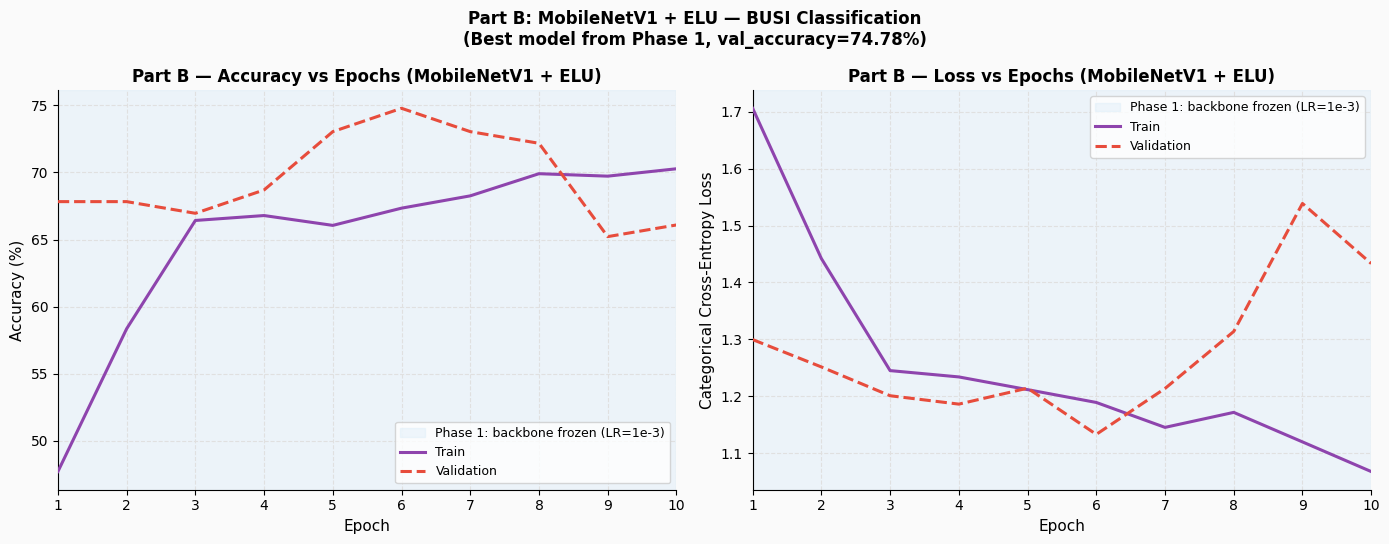

4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step

 Part B Test Evaluation 
Test images  : 120
Overall Accuracy: 75.00%

              precision    recall  f1-score   support

      Benign     0.8621    0.7463    0.8000        67
   Malignant     0.6389    0.7188    0.6765        32
      Normal     0.6538    0.8095    0.7234        21

    accuracy                         0.7500       120
   macro avg     0.7183    0.7582    0.7333       120
weighted avg     0.7661    0.7500    0.7537       120



In [ ]:
# step-14: Part B — training curves + test evaluation

# Phase 2 val_accuracy was worse than Phase 1, so Phase 1 best model was used.
history_b_plot = history_b_p1
epochs_b   = len(history_b_plot.history['accuracy'])
ep_b       = np.arange(1, epochs_b + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor('#FAFAFA')

for ax, (ytr, yv, title, ylabel) in zip(axes, [
    (np.array(history_b_plot.history['accuracy'])*100,
     np.array(history_b_plot.history['val_accuracy'])*100,
     'Part B — Accuracy vs Epochs (MobileNetV1 + ELU)', 'Accuracy (%)'),
    (history_b_plot.history['loss'], history_b_plot.history['val_loss'],
     'Part B — Loss vs Epochs (MobileNetV1 + ELU)', 'Categorical Cross-Entropy Loss'),
]):
    ax.set_facecolor('#F8F9FA')
    ax.grid(True, color='#E0E0E0', linewidth=0.8, linestyle='--')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.axvspan(1, epochs_b, alpha=0.35, color='#D6EAF8', label='Phase 1: backbone frozen (LR=1e-3)')
    ax.plot(ep_b, ytr, color='#8E44AD', lw=2.2, label='Train', zorder=4)
    ax.plot(ep_b, yv,  color='#E74C3C', lw=2.2, label='Validation', linestyle='--', zorder=4)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=11); ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xlim(1, epochs_b)
    ax.legend(fontsize=9, loc='lower right' if 'Acc' in title else 'upper right')

plt.suptitle('Part B: MobileNetV1 + ELU — BUSI Classification\n(Best model from Phase 1, val_accuracy=74.78%)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/partB_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Test evaluation
best_b = keras.models.load_model(f'{OUTPUT_DIR}/partB_final.keras')
X_test_b = np.zeros((len(test_recs), IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
for i, rec in enumerate(test_recs):
    X_test_b[i] = preprocess_image(rec['filepath'], augment=False, model_type='mobilenet')

y_pred_prob_b = best_b.predict(X_test_b, batch_size=BATCH_SIZE, verbose=1)
y_pred_b      = np.argmax(y_pred_prob_b, axis=1)

print('\n Part B Test Evaluation ')
print(f'Test images  : {len(y_true)}')
print(f'Overall Accuracy: {accuracy_score(y_true, y_pred_b)*100:.2f}%')
print()
print(classification_report(y_true, y_pred_b, target_names=CLASS_NAMES, digits=4))


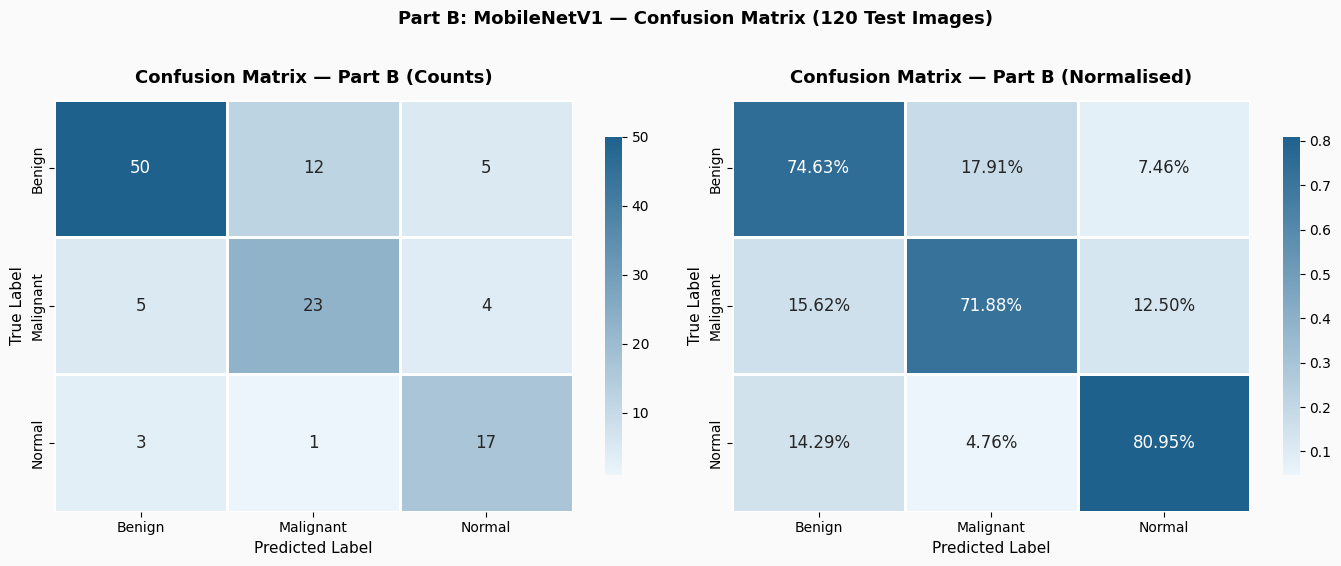

In [ ]:
# step-14b: Part B — confusion matrix
cm_b      = confusion_matrix(y_true, y_pred_b)
cm_b_norm = cm_b.astype(float) / cm_b.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor('#FAFAFA')
for ax, data, fmt, title in zip(axes, [cm_b, cm_b_norm], ['d', '.2%'],
    ['Confusion Matrix — Part B (Counts)', 'Confusion Matrix — Part B (Normalised)']):
    ax.set_facecolor('#FAFAFA')
    sns.heatmap(data, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.8, linecolor='white',
                cbar_kws={'shrink': 0.82}, ax=ax, annot_kws={'size': 12})
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
plt.suptitle(f'Part B: MobileNetV1 — Confusion Matrix ({len(y_true)} Test Images)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/partB_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

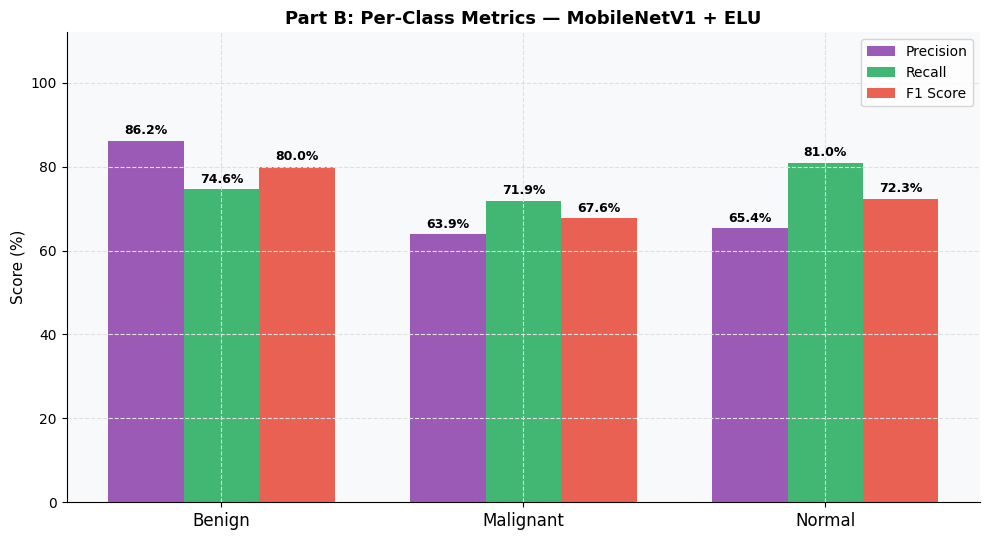

Part B — Macro F1: 0.7333


In [ ]:
# step-14c: Part B — per-class metrics
p_b, r_b, f1_b, _ = precision_recall_fscore_support(y_true, y_pred_b, labels=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.set_facecolor('#F8F9FA'); ax.grid(True, color='#E0E0E0', linewidth=0.8, linestyle='--')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
b1 = ax.bar(x-w, p_b*100, w, label='Precision', color='#8E44AD', alpha=0.88)
b2 = ax.bar(x,   r_b*100, w, label='Recall',    color='#27AE60', alpha=0.88)
b3 = ax.bar(x+w, f1_b*100,w, label='F1 Score',  color='#E74C3C', alpha=0.88)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.8, f'{h:.1f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, fontsize=12)
ax.set_ylabel('Score (%)', fontsize=11); ax.set_ylim(0, 112)
ax.set_title('Part B: Per-Class Metrics — MobileNetV1 + ELU', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/partB_per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

macro_f1_b = f1_score(y_true, y_pred_b, average='macro')
print(f'Part B — Macro F1: {macro_f1_b:.4f}')

In [ ]:
# step-15: final comparison table

print('=' * 70)
print('FINAL COMPARISON — Assignment 2 vs Assignment 3 Part A vs Part B')
print('=' * 70)
print(f'{"Model":<30} {"Acc":>8} {"MacroF1":>9} {"Trainable Params":>18}')
print('-' * 70)
print(f'{"Assignment 2 (ResNet50+ReLU)":<30} {"75.83%":>8} {"74.04%":>9} {"1,116,419":>18}')
print(f'{"Part A (ResNet50+DSC+ELU)":<30} {accuracy_score(y_true,y_pred_a)*100:>7.2f}% {macro_f1_a*100:>8.2f}% {trainable_a:>18,}')
print(f'{"Part B (MobileNetV1+ELU)":<30} {accuracy_score(y_true,y_pred_b)*100:>7.2f}% {macro_f1_b*100:>8.2f}% {trainable_b:>18,}')
print('=' * 70)
print()
print('DSC Computational Saving (K=3, Cout=512):')
ratio = (1/512) + (1/9)
print(f'  C(DSC)/C(RC) = 1/512 + 1/9 = {ratio:.4f}')
print(f'  Saving = {(1-ratio)*100:.1f}%')
print()
print('MobileNetV1 parameter reduction vs ResNet50:')
print(f'  {(1 - total_b/24705411)*100:.1f}% fewer parameters')

FINAL COMPARISON — Assignment 2 vs Assignment 3 Part A vs Part B
Model                               Acc   MacroF1   Trainable Params
----------------------------------------------------------------------
Assignment 2 (ResNet50+ReLU)     75.83%    74.04%          1,116,419
Part A (ResNet50+DSC+ELU)        67.50%    55.15%          1,143,939
Part B (MobileNetV1+ELU)         75.00%    73.33%            279,683

DSC Computational Saving (K=3, Cout=512):
  C(DSC)/C(RC) = 1/512 + 1/9 = 0.1131
  Saving = 88.7%

MobileNetV1 parameter reduction vs ResNet50:
  85.8% fewer parameters
